# Extra validations, ablations, supervised-reference using Synthetic data

In [1]:
import os, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from importlib import reload    

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "core").exists() and (REPO_ROOT.parent / "core").exists():
    os.chdir(REPO_ROOT.parent)
    REPO_ROOT = Path.cwd()
    
from core import config, data, infer, net, pipelines, train

from notebooks.nutils import get_coverage, get_mahalanobis_critical, plot_calibration_curve, plot_nn_vs_ref_coverage
from notebooks import nutils

import analyze_uncertainty as au

### Support choice of 0.1 as hyperparam

In [2]:
alpha_sweep_run_dir = 'figs/simulative_papermill_runs_2026-04-23_22h_ASWEEP'

In [3]:
os.listdir(alpha_sweep_run_dir)

['simulative_2026-04-23_22-10.ipynb',
 'simulative_2026-04-23_22-33.ipynb',
 'simulative_2026-04-24_00-08.ipynb',
 'simulative_2026-04-23_23-44.ipynb',
 'results_2026-04-23_22-57',
 'results_2026-04-23_22-33',
 'simulative_2026-04-23_22-57.ipynb',
 'results_2026-04-23_23-44',
 'results_2026-04-24_00-08',
 'results_2026-04-23_23-21',
 'simulative_2026-04-23_23-21.ipynb',
 'results_2026-04-23_22-10']

In [4]:
data4calib_to_ref_list = []

for subdir in sorted([p for p in Path(alpha_sweep_run_dir).iterdir() if p.is_dir()]):
    f = subdir / "intermediates/data4calib_to_ref.npz"
    print(f)
    if f.exists():
        with np.load(f) as z:
            data4calib_to_ref_list.append({k: z[k] for k in z.files})

len(data4calib_to_ref_list), data4calib_to_ref_list[0].keys()

figs/simulative_papermill_runs_2026-04-23_22h_ASWEEP/results_2026-04-23_22-10/intermediates/data4calib_to_ref.npz
figs/simulative_papermill_runs_2026-04-23_22h_ASWEEP/results_2026-04-23_22-33/intermediates/data4calib_to_ref.npz
figs/simulative_papermill_runs_2026-04-23_22h_ASWEEP/results_2026-04-23_22-57/intermediates/data4calib_to_ref.npz
figs/simulative_papermill_runs_2026-04-23_22h_ASWEEP/results_2026-04-23_23-21/intermediates/data4calib_to_ref.npz
figs/simulative_papermill_runs_2026-04-23_22h_ASWEEP/results_2026-04-23_23-44/intermediates/data4calib_to_ref.npz
figs/simulative_papermill_runs_2026-04-23_22h_ASWEEP/results_2026-04-24_00-08/intermediates/data4calib_to_ref.npz


(6, dict_keys(['cov_est_nn_arr', 'reference', 'fk_est_nn']))

In [5]:
data4calib_to_ref_list[0].keys()

dict_keys(['cov_est_nn_arr', 'reference', 'fk_est_nn'])

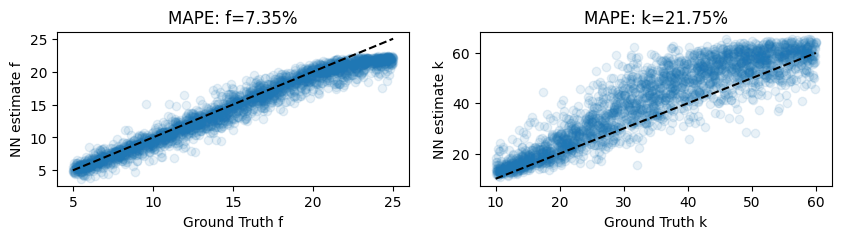

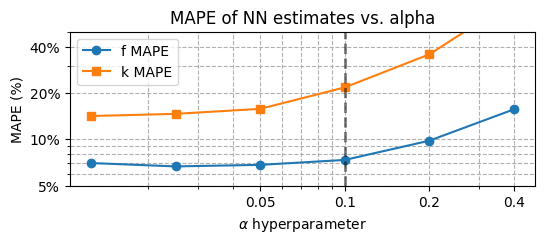

In [6]:
from matplotlib.ticker import NullFormatter

alphas = [0.0125, 0.025, 0.05, 0.1, 0.2, 0.4]
ind = 3

nutils.plot_fk_scatters(
    data4calib_to_ref_list[ind]['reference'][:, 0], data4calib_to_ref_list[ind]['reference'][:, 1], 
    data4calib_to_ref_list[ind]['fk_est_nn'][:, 0], data4calib_to_ref_list[ind]['fk_est_nn'][:, 1]
)
mapes = [
    nutils.plot_fk_scatters(d['reference'][:, 0], d['reference'][:, 1], d['fk_est_nn'][:, 0], d['fk_est_nn'][:, 1], visualize=False) 
    for d in data4calib_to_ref_list
]

def plot_mape_vs_alpha(alphas, mapes, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 2))
    ax.plot(alphas, [m[0] for m in mapes], 'o-', label='f MAPE')
    ax.plot(alphas, [m[1] for m in mapes], 's-', label='k MAPE')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylim(5, 50)
    ax.set_xlabel(r'$\alpha$ hyperparameter')
    ax.set_ylabel('MAPE (%)')
    ax.set_title('MAPE of NN estimates vs. alpha')
    ax.set_xticks([0.01, 0.05, 0.1, 0.2, 0.4], ['0.01', '0.05', '0.1', '0.2', '0.4'])
    ax.set_yticks([5, 10, 20, 40], ['5%', '10%', '20%', '40%'])
    ax.plot([0.1, 0.1], [5, 50], 'k--', linewidth=2, alpha=.5) #, label=r'The $\alpha$ elsewhere in the paper')
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.tick_params(axis='y', which='minor', labelleft=False)
    ax.legend()
    ax.grid(True, which='both', ls='--')

plot_mape_vs_alpha(alphas, mapes)

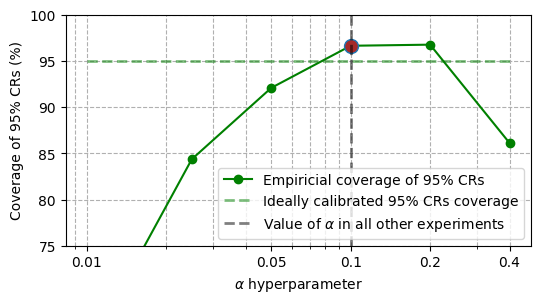

In [7]:

coverage_curves = [get_coverage(
        data4calib_to_ref_list[ind]['fk_est_nn'], data4calib_to_ref_list[ind]['reference'], data4calib_to_ref_list[ind]['cov_est_nn_arr']
        ) for ind in range(len(data4calib_to_ref_list))
        ]  

def plot_coverage_vs_alpha(alphas, coverage_curves):
    plt.figure(figsize=(6, 2))
    for cov_dict, alpha in zip(coverage_curves, alphas):
        plt.plot(list(cov_dict.keys()), list(cov_dict.values()), label=f'alpha={alpha:.3f}')
    plt.plot([0, 100], [0, 100], 'k--', label='Ideal')
    plt.xlabel('Nominal Coverage (%)')
    plt.ylabel('Empirical Coverage (%)')
    plt.title('Coverage of NN uncertainty estimates vs. alpha')
    plt.legend()
    plt.grid(True, which="both", ls="--")

def plot_coverage95_vs_alpha(alphas, coverage_curves, ax=None):
    if ax is None:
        plt.figure(figsize=(6, 3))
        ax = plt.gca()    
    cov95 = [cov_dict[95] for cov_dict in coverage_curves]
    plt.plot(alphas, cov95, 'go-', label='Empiricial coverage of 95% CRs')    
    plt.plot(alphas[-3:-2], cov95[-3:-2], 'o', markerfacecolor='brown', markersize=10)    
    plt.ylabel('Coverage of 95% CRs (%)')
    plt.ylim(75, 100)    
    ax.set_xlabel(r'$\alpha$ hyperparameter')
    ax.set_xscale('log')    
    ax.set_xticks([0.01, 0.05, 0.1, 0.2, 0.4], ['0.01', '0.05', '0.1', '0.2', '0.4'])
    plt.plot([0.01, 0.4], [95, 95], 'g--', linewidth=2, alpha=0.5, label='Ideally calibrated 95% CRs'' coverage')
    ax.plot([0.1, 0.1], [75, 100], 'k--', linewidth=2, alpha=.5, label=r'Value of $\alpha$ in all other experiments')
    plt.grid(True, which="both", ls="--")    
    
    plt.legend()
    
plot_coverage95_vs_alpha(alphas, coverage_curves)


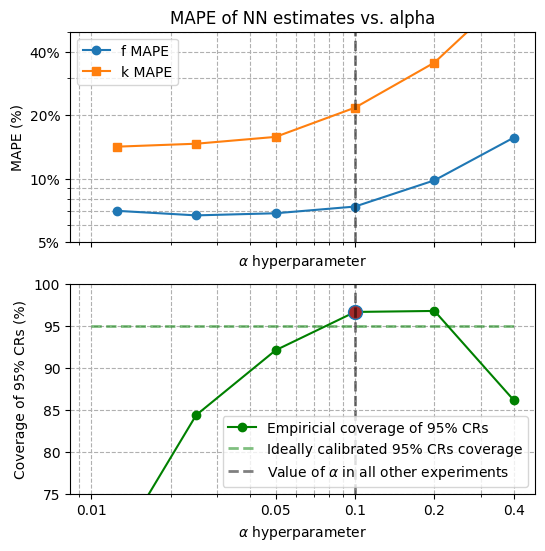

In [8]:

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 6))
plot_mape_vs_alpha(alphas, mapes, ax=ax1)
plot_coverage95_vs_alpha(alphas, coverage_curves, ax=ax2)

### Show coverage curves robustness vs. reference

In [9]:

no_bias_npz = '/home/alexf/phiVAE/figs/simulative_papermill_runs_2026-04-27_09h_MISS_small/results_2026-04-27_09-37/intermediates/MT_UQ_stats_allpoints.npz'
with_bias_npz = '/home/alexf/phiVAE/figs/simulative_papermill_runs_2026-04-27_09h_MISS_small/results_2026-04-27_10-02/intermediates/MT_UQ_stats_allpoints.npz'

(100, 2) (100, 2) (100, 2, 2)
(100, 2) (100, 2) (100, 2, 2)


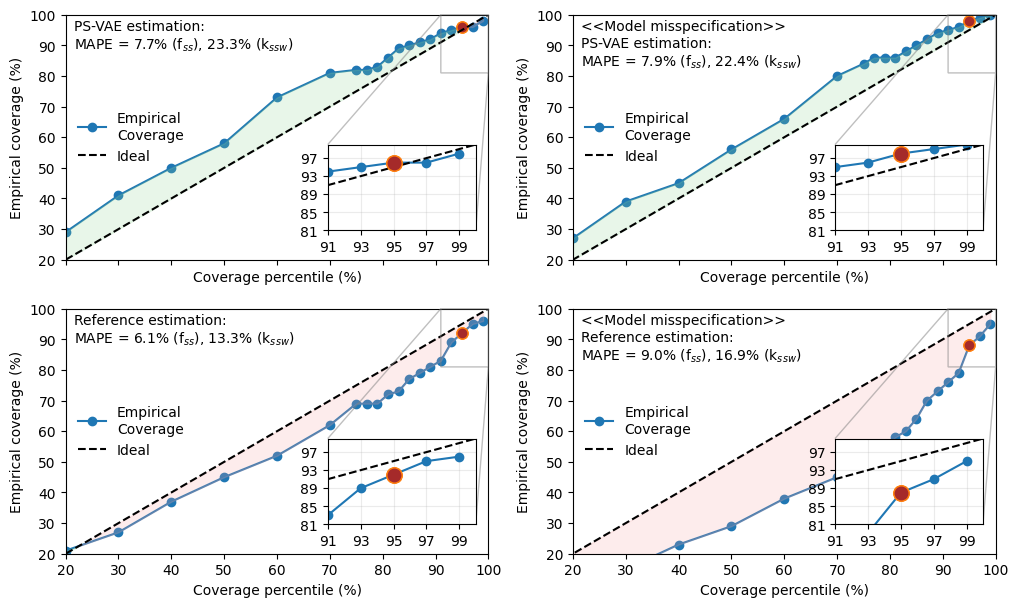

In [10]:
if True:
    fig, axes = plt.subplots(2, 2, sharex=True, figsize=(12, 7))
    plot_nn_vs_ref_coverage(no_bias_npz, axes=axes[:, 0])
    plot_nn_vs_ref_coverage(with_bias_npz, axes=axes[:, 1], txtprefix="<<Model misspecification>>\n")

### Ablation of diagonal covariance

In [11]:
from notebooks import nutils
reload(nutils)
nutils.config4sim()
datafeed_mt, mt_sim_mode, noise_norm = nutils.synthesize_data(data_shape=(40,1,50))

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:04<00:00,  4.12s/it]


In [12]:
update_persistent_synthetic_dict_instance = False
if update_persistent_synthetic_dict_instance:
    np.savez(
        'figs/simulative/freeze_synth.npz',
        R1a=datafeed_mt.R1a_V, R2a=datafeed_mt.R2a_V, B0_shift_ppm_map=datafeed_mt.B0_shift_ppm_map, B1_fix_factor_map=datafeed_mt.B1_fix_factor_map,
        kc_gt_T=datafeed_mt.kc_gt_T, fc_gt_T=datafeed_mt.fc_gt_T, measured_normed_T=datafeed_mt.measured_normed_T,
        allow_pickle=True
    )

use_persistent_synthetic_dict_instance = True    
if use_persistent_synthetic_dict_instance:
    frozen = np.load('figs/simulative/freeze_synth.npz', allow_pickle=True)
    datafeed_mt.R1a_V = frozen['R1a']
    datafeed_mt.R2a_V = frozen['R2a']
    datafeed_mt.B0_shift_ppm_map = frozen['B0_shift_ppm_map']
    datafeed_mt.B1_fix_factor_map = frozen['B1_fix_factor_map']
    datafeed_mt.kc_gt_T = frozen['kc_gt_T']
    datafeed_mt.fc_gt_T = frozen['fc_gt_T']
    datafeed_mt.measured_normed_T = frozen['measured_normed_T']

(100, 2) (100, 2) (100, 2, 2)


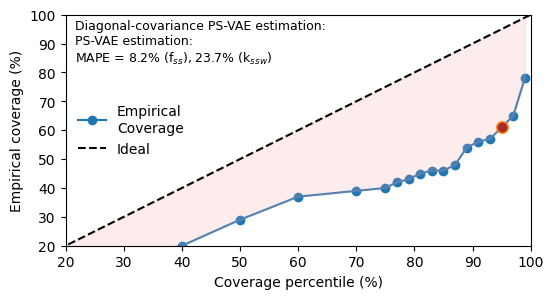

In [13]:
diag_experiment_dir = '/home/alexf/phiVAE/figs/simulative_papermill_runs_2026-04-26_17h_DIAG/results_2026-04-26_17-13'
diag_npz = diag_experiment_dir + "/intermediates/MT_UQ_stats_allpoints.npz"
fig, ax = plt.subplots(1, 1, sharex=True, figsize=(6, 3))
plot_nn_vs_ref_coverage(diag_npz, txtprefix="Diagonal-covariance PS-VAE estimation:\n", fontsize=9, axes=[ax, None], do_inset=False)

In [14]:
full_conv_exp_dir = "/home/alexf/phiVAE/figs/simulative_papermill_runs_2026-04-27_09h_MISS_small/results_2026-04-27_09-37"
full_conv_exp_dir = "/home/alexf/phiVAE/figs/simulative_papermill_runs_2026-04-23_22h_ASWEEP/results_2026-04-23_23-21"  # 0.1

mt_tissue_params_est_FULLCONV, nn_est_dict_FULLCOV = nutils.infer_ckpt(full_conv_exp_dir + "/ckpts/mt", datafeed_mt, mt_sim_mode)
mt_tissue_params_est_DIAGCOV, nn_est_dict_DIAGCOV = nutils.infer_ckpt(diag_experiment_dir + "/ckpts/mt", datafeed_mt, mt_sim_mode, force_diag=True)

/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.85s/it]
/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this op

(2000, 2) (2000, 2) (2000, 2, 2)
(2000, 2) (2000, 2) (2000, 2, 2)


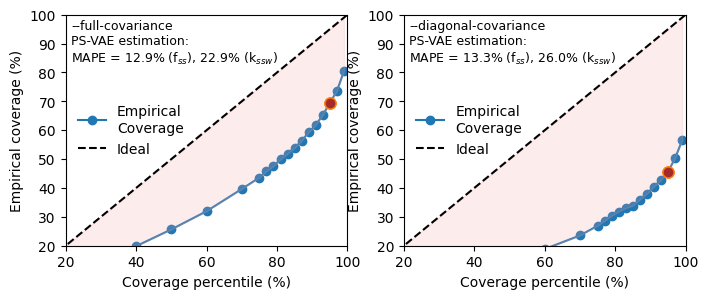

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
plot_nn_vs_ref_coverage(
    gt_reference=np.stack((100*datafeed_mt.fc_gt_T.flatten(), datafeed_mt.kc_gt_T.flatten()), axis=1),    
    fk_est_nn=np.stack((nn_est_dict_FULLCOV['f'].flatten(), nn_est_dict_FULLCOV['k'].flatten()), axis=1),
    cov_est_nn_arr=nn_est_dict_FULLCOV['cov_nnpred_scaled'].reshape(-1, 2, 2),
    txtprefix="--full-covariance\n", fontsize=9, axes=[axes[0], None], do_inset=False
)
inflation_factor_diag = 1  # roughly 4 is needed to get "in the green"
plot_nn_vs_ref_coverage(
    gt_reference=np.stack((100*datafeed_mt.fc_gt_T.flatten(), datafeed_mt.kc_gt_T.flatten()), axis=1),    
    fk_est_nn=np.stack((nn_est_dict_DIAGCOV['f'].flatten(), nn_est_dict_DIAGCOV['k'].flatten()), axis=1),
    cov_est_nn_arr=nn_est_dict_DIAGCOV['cov_nnpred_scaled'].reshape(-1, 2, 2)*inflation_factor_diag,
    txtprefix="--diagonal-covariance\n", fontsize=9, axes=[axes[1], None], do_inset=False
)

In [16]:
import analyze_uncertainty as au
reload(au.viz); reload(au)
au.au_config.loc_dict_res = 200
au.core.au_config.known_gt = True 

In [17]:
_tst=False
if _tst:
    _cp_res = au.compare_posteriors(  
        [(x,x) for x in range(20)], datafeed_mt, mt_tissue_params_est_DIAGCOV,
        mt_sim_mode=mt_sim_mode, sli=0, voxels2sample=5, folder_name='tmp', visualize=True,    
    )

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:04<00:00,  4.32s/it]

nrmse_95_th 0.037936135961067464 cdf95 0.9478095312736322


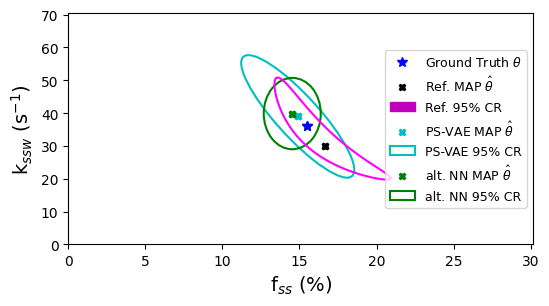

In [18]:
def viz_gt_ref_2nn(ax, synthetic_datafeed_mt, nn_est_dict_FULLCOV, nn_est_dict_DIAGCOV, _x, _y, do_heatmap=False, do_legend=True, alt_NN_name=None):
    gt = 100*synthetic_datafeed_mt.fc_gt_T[_x, 0, _y], synthetic_datafeed_mt.kc_gt_T[_x, 0, _y]
    (_1, _2, _3, nrmse, _df, _dk) = au.get_nrmse_grid(
        None, _x, _y, 0, synthetic_datafeed_mt, None, mt_sim_mode=mt_sim_mode,                
        )                    
    au.viz.viz_posteriors_two_nn(ax, nrmse, gt=gt, do_heatmap=do_heatmap, do_legend=do_legend, alt_NN_name=alt_NN_name,
        nn_est1={k:v[_x, 0, _y] for k, v in nn_est_dict_FULLCOV.items()}, 
        nn_est2={k:v[_x, 0, _y] for k, v in nn_est_dict_DIAGCOV.items() },     
    )    
    
for _x, _y in [(x,x) for x in range(3,4)]: #10)] :# (0, 0) range(3,5
    fig, ax = plt.subplots(1, 1, figsize=(6, 3))
    viz_gt_ref_2nn(ax, datafeed_mt, nn_est_dict_FULLCOV, nn_est_dict_DIAGCOV, _x, _y)
    plt.show()

### Ablation of MC-dropout and ensemble

In [19]:
from notebooks import nutils
reload(nutils); reload(net)
reload(au.viz); reload(au)
au.au_config.known_gt = True

In [20]:
mcdropout_results_dir = '/home/alexf/phiVAE/figs/simulative/results_2026-05-17_18-21'
ensemble_results_dir = '/home/alexf/phiVAE/figs/simulative/results_2026-05-14_20-15'


def summarize_mcdropout_and_ensemble_results(
    mcdropout_results_dir='/home/alexf/phiVAE/figs/simulative/results_2026-05-17_18-21',
    ensemble_results_dir='/home/alexf/phiVAE/figs/simulative/results_2026-05-14_20-15',
    fig=None, xy_samples=((0,3), (0,4)), inflation=1
    ):
    best_mcdropout_npz = f'{mcdropout_results_dir}/intermediates/data4calib_to_ref.npz'
    ensemble_npz = f'{ensemble_results_dir}/intermediates/data4calib_to_ref.npz'

    if fig is None:
        fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    else:
        axes = fig.subplots(2, 3)

    try:    
        mcd_data = np.load(best_mcdropout_npz)
        nutils.plot_nn_vs_ref_coverage(
            gt_reference=mcd_data['reference'], fk_est_nn=mcd_data['fk_est_nn'], cov_est_nn_arr=mcd_data['cov_est_nn_arr']*inflation,
            txtprefix="MC-Dropout-based probabilistic inference\n(supervised learning):\n", fontsize=9, axes=[axes[0, 0], None], do_inset=False, est_method=""
        )

        ensemble_data = np.load(ensemble_npz)
        nutils.plot_nn_vs_ref_coverage(
            gt_reference=ensemble_data['reference'], fk_est_nn=ensemble_data['fk_est_nn'], cov_est_nn_arr=ensemble_data['cov_est_nn_arr']*inflation,
            txtprefix="Ensemble-based probabilistic inference\n(supervised learning):\n", fontsize=9, axes=[axes[1, 0], None], do_inset=False, est_method=""
        )
    except Exception as e:
        print(f"Error loading/processing MC-Dropout or Ensemble predictor data: {e}")

    def _plot_couple_examples(_axes, nn_pred_dict, f_est, k_est, fk_diff, _xy=xy_samples, alt_NN_name=None):
        for jj, (_ax, (_x, _y)) in enumerate(zip(_axes, _xy)):

            num_samples = fk_diff.shape[0]    
            gt = 100*datafeed_mt.fc_gt_T[_x, 0, _y], datafeed_mt.kc_gt_T[_x, 0, _y]
            (_1, _2, _3, nrmse, _df, _dk) = au.get_nrmse_grid(
                None, _x, _y, 0, datafeed_mt, None, mt_sim_mode=mt_sim_mode,                
            )    
            au.viz.viz_posteriors_two_nn(
                _ax, nrmse, nn_est1=None, nn_est2=None, gt=gt, 
                n_meas=31, _df=None, _dk=None, linewidth=1.5, markersize=5, is_cest=False, fontsize=14, do_heatmap=False, do_legend=jj,            
                nn_colors = ("g",)*(num_samples+1), ellipse_linestyle='--', with_PSVAE=False, alt_NN_name=alt_NN_name,
                nn_est_list=[{k:v[_x, 0, _y] for k, v in nn_pred_dict.items()}] + \
                    [{'f': f_est[_x, 0, _y]+fk_diff[jj, 0, _x, 0, _y], 'k': k_est[_x, 0, _y]+fk_diff[jj, 1, _x, 0, _y], 'width': 0, 'height': 0, 'angle': 0} for jj in range(num_samples)]
            )        

    try:        
        stochastic_predictor = nutils.get_stochastic_predictor(ckpt_folder=mcdropout_results_dir + "/ckpts/supervised/mt_single") 
        f_est, k_est, cov_nnpred_scaled, fk_diff = nutils.extract_mc_dropout_uncertainty(stochastic_predictor, datafeed_mt, num_samples=20, use_vmap=False) #0)
        height, width, angle = nutils.cov2ellipse(cov_nnpred_scaled)   
        nn_pred_dict = {'width': width*inflation, 'height': height*inflation, 'angle': angle, 'f': f_est, 'k': k_est, 'cov_nnpred_scaled': cov_nnpred_scaled}
        _plot_couple_examples(axes[0, 1:], nn_pred_dict, f_est, k_est, fk_diff, alt_NN_name="MC-Dropout")
    except Exception as e:
        print(f"Error loading/processing MC-Dropout predictor: {e}")
        raise e

    ens_ckpts_folder = ensemble_results_dir + "/ckpts/supervised/mt_ens"
    ensemble_size = 5
    predictors_ensemble = [net.load_ckpt(ens_ckpts_folder+f'/{jj}', enable_dropout=False)[0] for jj in range(ensemble_size)]
    f_est, k_est, cov_nnpred_scaled, fk_diff = nutils.extract_ensemble_uncertainty(predictors_ensemble, datafeed_mt, mt_sim_mode=mt_sim_mode) 
    height, width, angle = nutils.cov2ellipse(cov_nnpred_scaled)   
    nn_pred_dict = {'width': width*inflation, 'height': height*inflation, 'angle': angle, 'f': f_est, 'k': k_est, 'cov_nnpred_scaled': cov_nnpred_scaled}
    _plot_couple_examples(axes[1, 1:], nn_pred_dict, f_est, k_est, fk_diff, alt_NN_name="Ensemble")
    

In [21]:
#mcdropout_results_dir + "/ckpts/supervised/mt_single"

In [22]:
#!ls /home/alexf/phiVAE/figs/simulative/results_2026-05-14_20-15/ckpts/mt_ens/
#!ls /home/alexf/phiVAE/figs/simulative/results_2026-05-07_20-55/ckpts
#!ls '/home/alexf/phiVAE/figs/simulative/results_2026-05-17_17-58/ckpts/supervised/mt_single'


## FINAL FIGURE - Simulative (Fig. 2)

(100, 2) (100, 2) (100, 2, 2)
(100, 2) (100, 2) (100, 2, 2)
(100, 2) (100, 2) (100, 2, 2)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.71s/it]


nrmse_95_th 0.037936135961067464 cdf95 0.9478095312736322


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.67s/it]
/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


nrmse_95_th 0.028426240312834018 cdf95 0.9509255730515058
(10000, 2) (10000, 2) (10000, 2, 2)
(10000, 2) (10000, 2) (10000, 2, 2)
use_vmap False
Using loop for stochastic forward passes


...

cov_scaled.shape (40, 1, 50, 2, 2)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.61s/it]


nrmse_95_th 0.037936135961067464 cdf95 0.9478095312736322


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.58s/it]


nrmse_95_th 0.028426240312834018 cdf95 0.9509255730515058


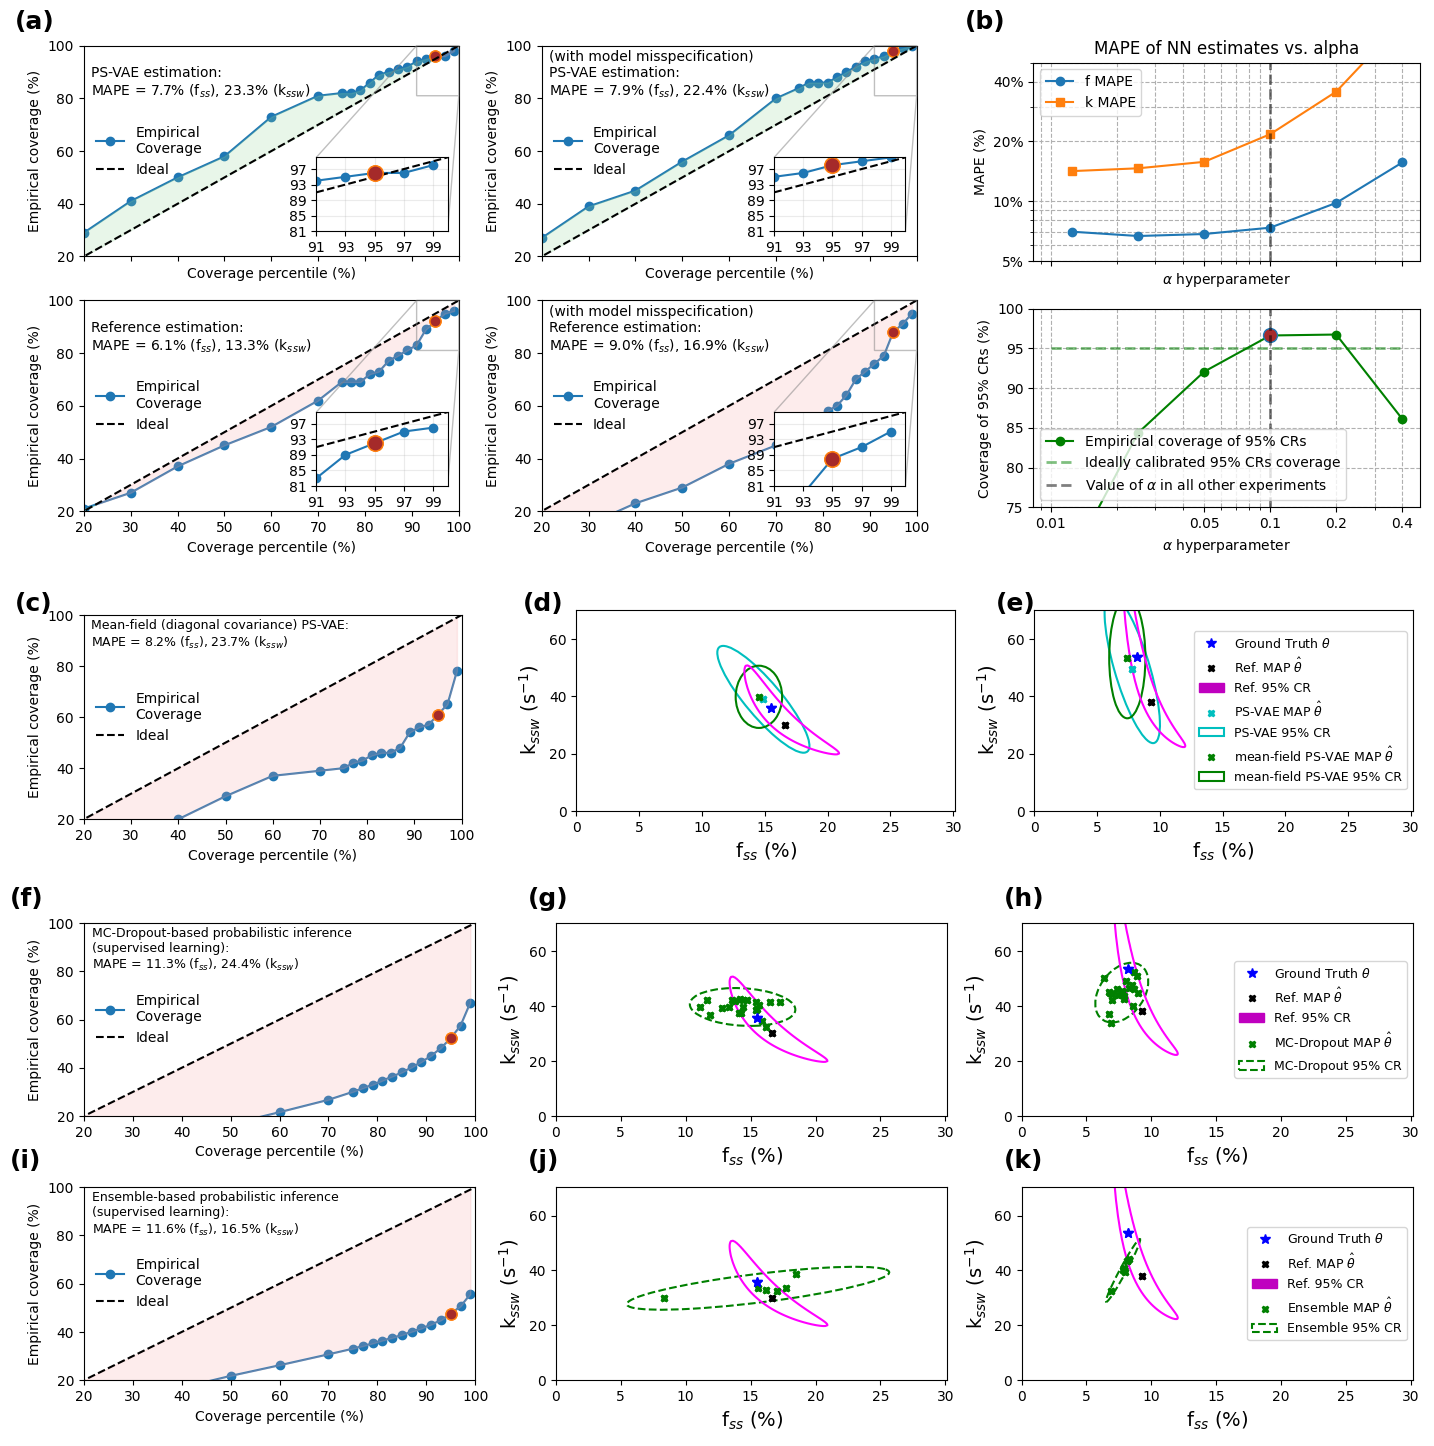

In [25]:
reload(nutils); nutils.config4sim()

def slap_label_on_container(container, label_text, loc=(-0.01, 1.05), color='black', fontsize=18):    
    ghost_ax = container.add_axes([0, 0, 1, 1], frameon=False)        
    ghost_ax.set_xticks([]); ghost_ax.set_yticks([])        
    ghost_ax.text(
        loc[0], loc[1], label_text, transform=ghost_ax.transAxes, 
        fontsize=fontsize, fontweight='bold', va='top', ha='left', 
        color=color
    )

fig = plt.figure(figsize=(14, 14), constrained_layout=True) # 16, 6           
subfig_rows = fig.subfigures(3, 1, height_ratios=[1, 0.5, 1], hspace=0.1)

toprow_subfigs = subfig_rows[0].subfigures(1, 2, width_ratios=[2, 1], wspace=0.05)

subfig = toprow_subfigs[0] # subfigs[0, 0]
slap_label_on_container(subfig, "(a)")
axes = subfig.subplots(2, 2, sharex=True) #, figsize=(12, 7))
nutils.plot_nn_vs_ref_coverage(no_bias_npz, axes=axes[:, 0], txtprefix="\n")
nutils.plot_nn_vs_ref_coverage(with_bias_npz, axes=axes[:, 1], txtprefix="(with model misspecification)\n")

subfig = toprow_subfigs[1] # subfigs[0, 1]
slap_label_on_container(subfig, "(b)")
(ax1, ax2) = subfig.subplots(2, 1, sharex=True) #, figsize=(6, 6))
plot_mape_vs_alpha(alphas, mapes, ax=ax1)
plot_coverage95_vs_alpha(alphas, coverage_curves, ax=ax2)

bottom_row_subfigs = subfig_rows[1].subfigures(1, 2, width_ratios=[1, 2], wspace=0.05)
subfig = bottom_row_subfigs[0] # subfigs[1, 0]
slap_label_on_container(subfig, "(c)", loc=(-0.02, 1.05))
ax = subfig.subplots(1, 1)
nutils.plot_nn_vs_ref_coverage(diag_npz, txtprefix="Mean-field (diagonal covariance) PS-VAE:\n", est_method="", fontsize=9, axes=[ax, None], do_inset=False)

subfig = bottom_row_subfigs[1] # subfigs[1, 0]
slap_label_on_container(subfig, "(d)", loc=(0.01, 1.05))
slap_label_on_container(subfig, "(e)", loc=(0.53, 1.05))
axes = subfig.subplots(1, 2) 

xy_samples=((3,3), (5,5)) # ((0,3), (0,4))

for jj, (ax, (_x, _y)) in enumerate(zip(axes, xy_samples)):
    viz_gt_ref_2nn(ax, datafeed_mt, nn_est_dict_FULLCOV, nn_est_dict_DIAGCOV, _x, _y, do_legend=jj, alt_NN_name="mean-field PS-VAE")
    
extrafig = subfig_rows[2]
summarize_mcdropout_and_ensemble_results(fig=extrafig, xy_samples=xy_samples)
slap_label_on_container(extrafig, "(f)")
slap_label_on_container(extrafig, "(g)", loc=(0.36, 1.05))
slap_label_on_container(extrafig, "(h)", loc=(0.7, 1.05))
slap_label_on_container(extrafig, "(i)", loc=(-0.01, 0.55))
slap_label_on_container(extrafig, "(j)", loc=(0.36, .55))
slap_label_on_container(extrafig, "(k)", loc=(0.7, .55))

plt.savefig('figs/simulative/digital_phantom.png', dpi=300, bbox_inches='tight')
plt.savefig('figs/simulative/digital_phantom_LOWRES.png', dpi=100, bbox_inches='tight')

## extra validations

### the plots of CIs vs. true error (for both methods), for further consideration

In [ ]:
mt_tissue_params_est_FULLCONV, nn_est_dict_FULLCOV = nutils.infer_ckpt(full_conv_exp_dir + "/ckpts/mt", datafeed_mt, mt_sim_mode)
nn_est_dict_FULLCOV.keys()

/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 28.05it/s]


dict_keys(['width', 'height', 'angle', 'f', 'k', 'cov_nnpred_scaled', 'f_sigma', 'k_sigma'])

(7.226236405177458, 20.983402556186544)

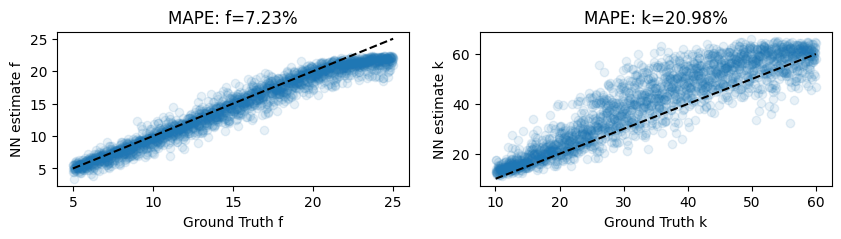

In [ ]:
nutils.plot_fk_scatters(    
    100*datafeed_mt.fc_gt_T.flatten(), datafeed_mt.kc_gt_T.flatten(),
    nn_est_dict_FULLCOV['f'].flatten(), nn_est_dict_FULLCOV['k'].flatten(), 
)

In [ ]:
np.sum(np.abs(100*datafeed_mt.fc_gt_T.flatten() - nn_est_dict_FULLCOV['f'].flatten()) < 2 * nn_est_dict_FULLCOV['f_sigma'].flatten()) / nn_est_dict_FULLCOV['f'].flatten().shape[0], \
 np.sum(np.abs(datafeed_mt.kc_gt_T.flatten() - nn_est_dict_FULLCOV['k'].flatten()) < 2 * nn_est_dict_FULLCOV['k_sigma'].flatten()) / nn_est_dict_FULLCOV['k'].flatten().shape[0]

(0.937, 0.977)

(2000, 2) (2000, 2) (2000, 2, 2)


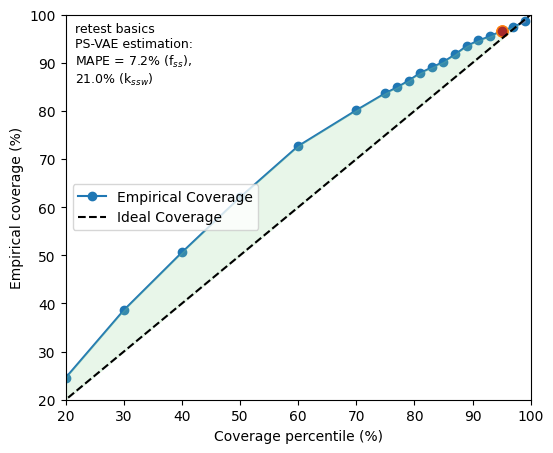

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
plot_nn_vs_ref_coverage(
    gt_reference=np.stack((100*datafeed_mt.fc_gt_T.flatten(), datafeed_mt.kc_gt_T.flatten()), axis=1),    
    fk_est_nn=np.stack((nn_est_dict_FULLCOV['f'].flatten(), nn_est_dict_FULLCOV['k'].flatten()), axis=1),
    cov_est_nn_arr=nn_est_dict_FULLCOV['cov_nnpred_scaled'].reshape(-1, 2, 2),
    txtprefix="retest basics\n", fontsize=9, axes=[ax, None], do_inset=False
)

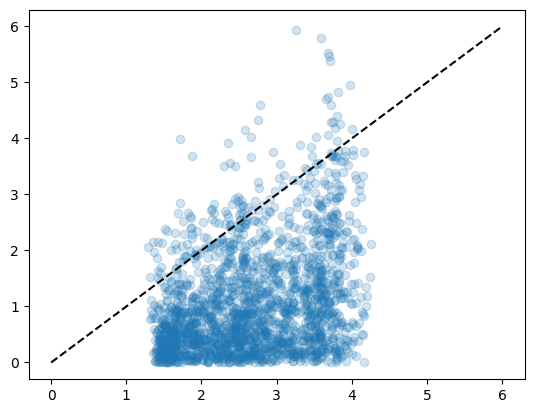

In [ ]:
plt.scatter(2*nn_est_dict_FULLCOV['f_sigma'].flatten(), np.abs(100*datafeed_mt.fc_gt_T.flatten() - nn_est_dict_FULLCOV['f'].flatten()), alpha=0.2)
plt.plot((0,6), (0,6), 'k--')

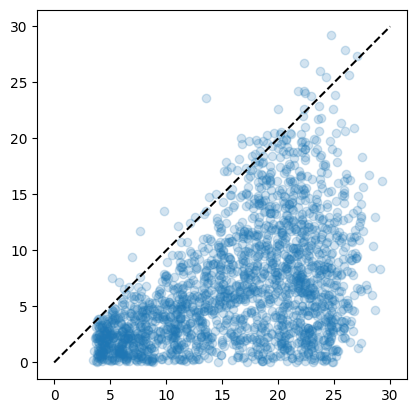

In [ ]:
plt.scatter(2*nn_est_dict_FULLCOV['k_sigma'].flatten(), np.abs(datafeed_mt.kc_gt_T.flatten() - nn_est_dict_FULLCOV['k'].flatten()), alpha=0.2)
plt.plot((0,30), (0,30), 'k--')
plt.gca().set_aspect('equal')

# Fig 8 - ablations (MCdropout/Ensemble) in-vivo

In [61]:
import xarray as xr 
inflation = 1
mcdropout_results_dir='/home/alexf/phiVAE/figs/simulative/results_2026-05-17_18-21'
ensemble_results_dir='/home/alexf/phiVAE/figs/simulative/results_2026-05-14_20-15'
xy_samples=((30,30), (60,60))
mt_sim_mode = 'isar2_c'
config.Config.configure_AMIDE_clinical_whole_brain()    

def _plot_couple_examples(_axes, datafeed_mt, nn_pred_dict, f_est, k_est, fk_diff, _xy=xy_samples, nrmses=None, sli=15, do_plot_points=True):
    for jj, (_ax, (_x, _y)) in enumerate(zip(_axes, _xy)):

        num_samples = fk_diff.shape[0]    
        if nrmses is not None:
            nrmse = nrmses[jj]
        else:
            (_1, _2, _3, nrmse, _df, _dk) = au.get_nrmse_grid(
                None, _x, _y, sli, datafeed_mt, None, mt_sim_mode=mt_sim_mode,                
            )    
        nn_est_list = [{k:v[_x, sli, _y] for k, v in nn_pred_dict.items()}]
        if do_plot_points:
            nn_est_list += [{'f': f_est[_x, sli, _y]+fk_diff[jj, 0, _x, sli, _y], 'k': k_est[_x, sli, _y]+fk_diff[jj, 1, _x, sli, _y], 'width': 0, 'height': 0, 'angle': 0} for jj in range(num_samples)]  
        au.viz.viz_posteriors_two_nn(
            _ax, nrmse, nn_est1=None, nn_est2=None, gt=None, 
            n_meas=31, _df=None, _dk=None, linewidth=1.5, markersize=5, is_cest=False, fontsize=14, do_heatmap=False, do_legend=False,            
            nn_colors = ("g",)*(num_samples+1), 
            nn_est_list=nn_est_list
        )        

data_xa = xr.open_dataset('./data/vol8.nc')
datafeed_mt = data.SlicesFeed.from_xarray(data_xa, seq_name='mt')
ckpt_folder = '/home/alexf/phiVAE/ckpts/healthy/vol7-9-10_2026-04-28_h22-m45'
mt_tissue_params_est, mt_nn_est_dict = nutils.infer_ckpt(f'{ckpt_folder}/mt', datafeed_mt, mt_sim_mode=mt_sim_mode)
f_est, k_est, cov_nnpred_scaled, f_sigma, k_sigma, height, width, angle = \
    au.extract_nn_estimate_of_posterior(mt_tissue_params_est, datafeed_mt.shape, is_cest=False)  
psvae_nn_pred_dict = {'width': width, 'height': height, 'angle': angle, 'f': f_est, 'k': k_est, 'cov_nnpred_scaled': cov_nnpred_scaled}

/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 27.28it/s]


In [59]:
nrmses_per_xysamples = [au.get_nrmse_grid(None, _x, _y, 15, datafeed_mt, None, mt_sim_mode=mt_sim_mode)[3] for _x, _y in xy_samples]

  0%|                                                                                                                                                                                                                                         | 0/1 [00:00<?, ?it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.45s/it]


### experimenting

In [ ]:

_ = au.compare_posteriors(
    xy_samples, datafeed_mt, mt_tissue_params_est,
    mt_sim_mode=mt_sim_mode, sli=15, voxels2sample=5, folder_name='/tmp', visualize=True
)

axes = plt.subplots(2, 3, figsize=(12, 7))[1]
try:        
    stochastic_predictor = nutils.get_stochastic_predictor(ckpt_folder=mcdropout_results_dir + "/ckpts/supervised/mt_single") 
    f_est, k_est, cov_nnpred_scaled, fk_diff = nutils.extract_mc_dropout_uncertainty(stochastic_predictor, datafeed_mt, num_samples=20, use_vmap=False) #0)    
    height, width, angle = nutils.cov2ellipse(cov_nnpred_scaled)   
    nn_pred_dict = {'width': width*inflation, 'height': height*inflation, 'angle': angle, 'f': f_est, 'k': k_est, 'cov_nnpred_scaled': cov_nnpred_scaled}
    _plot_couple_examples(axes[0, 1:], datafeed_mt, nn_pred_dict, f_est, k_est, fk_diff, sli=15)
except Exception as e:
    print(f"Error loading/processing MC-Dropout predictor: {e}")
    raise e

ens_ckpts_folder = ensemble_results_dir + "/ckpts/supervised/mt_ens"
ensemble_size = 5
predictors_ensemble = [net.load_ckpt(ens_ckpts_folder+f'/{jj}', enable_dropout=False)[0] for jj in range(ensemble_size)]
if False:
    f_est, k_est, cov_nnpred_scaled, fk_diff = nutils.extract_ensemble_uncertainty(predictors_ensemble, datafeed_mt, mt_sim_mode=mt_sim_mode) 
    height, width, angle = nutils.cov2ellipse(cov_nnpred_scaled)   
    nn_pred_dict = {'width': width*inflation, 'height': height*inflation, 'angle': angle, 'f': f_est, 'k': k_est, 'cov_nnpred_scaled': cov_nnpred_scaled}
    _plot_couple_examples(axes[1, 1:], datafeed_mt, nn_pred_dict, f_est, k_est, fk_diff, sli=15)

/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


use_vmap False
Using loop for stochastic forward passes


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 23.25it/s]


array([[<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

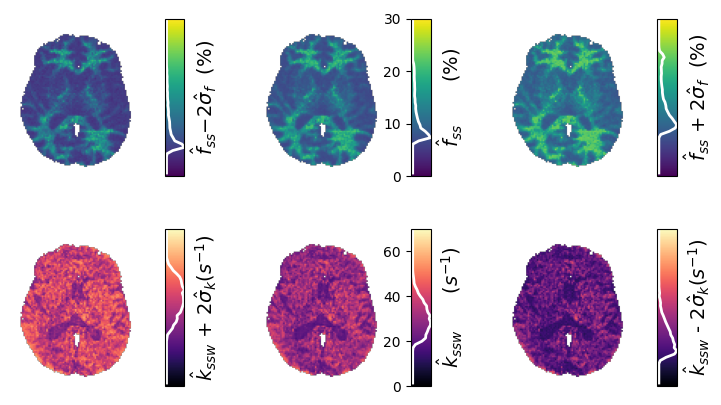

In [ ]:
sli=15

stochastic_predictor = nutils.get_stochastic_predictor(ckpt_folder=mcdropout_results_dir + "/ckpts/supervised/mt_single") 
if False:
    f_est, k_est, cov_nnpred_scaled, fk_diff = nutils.extract_mc_dropout_uncertainty(stochastic_predictor, datafeed_mt, num_samples=20, use_vmap=False) #0)       
    au.viz.plot_CI_maps(f_est[:,sli,:], np.sqrt(cov_nnpred_scaled[:,sli,:, 0,0]), k_est[:,sli,:], np.sqrt(cov_nnpred_scaled[:,sli,:, 1,1]), is_cest=False, figsize=(9, 5))

/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 23.48it/s]


array([[<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

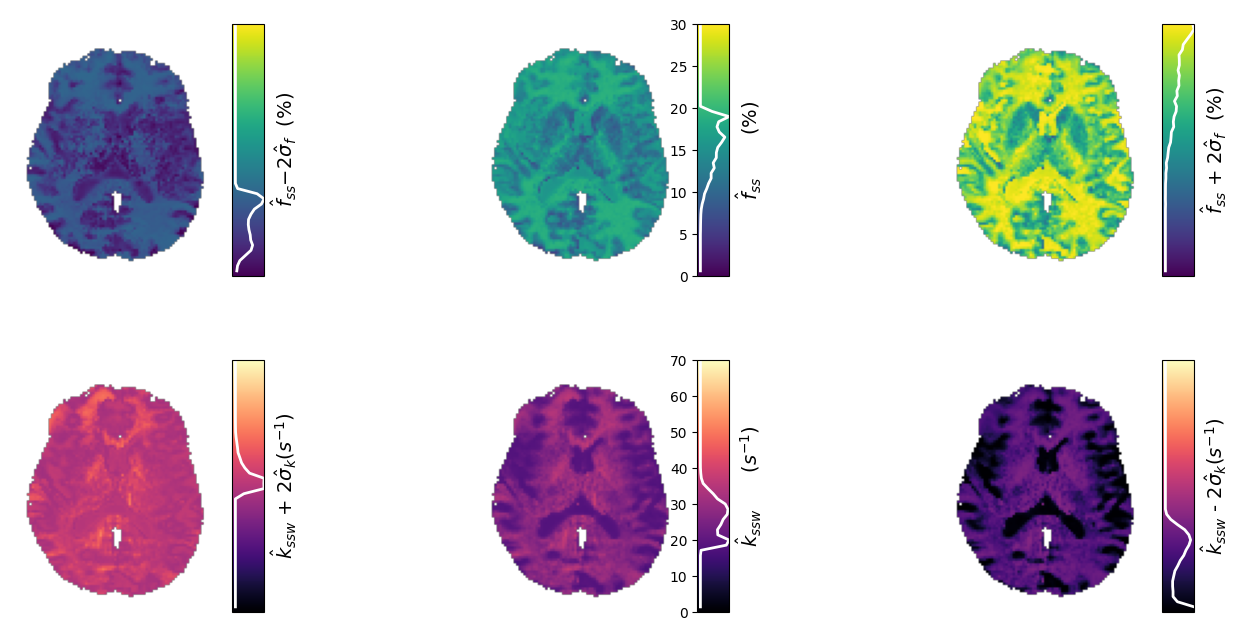

In [ ]:
predictors_ensemble = [net.load_ckpt(ens_ckpts_folder+f'/{jj}', enable_dropout=False)[0] for jj in range(ensemble_size)]
if False:
    f_est, k_est, cov_nnpred_scaled, fk_diff = nutils.extract_ensemble_uncertainty(predictors_ensemble, datafeed_mt, mt_sim_mode=mt_sim_mode) 
    au.viz.plot_CI_maps(f_est[:,sli,:], np.sqrt(cov_nnpred_scaled[:,sli,:, 0,0]), k_est[:,sli,:], np.sqrt(cov_nnpred_scaled[:,sli,:, 1,1]), is_cest=False)

In [36]:
stochastic_predictor = nutils.get_stochastic_predictor(ckpt_folder=mcdropout_results_dir + "/ckpts/supervised/mt_single") 
f_est_mcd, k_est_mcd, cov_nnpred_scaled_mcd, fk_diff_mcd = nutils.extract_mc_dropout_uncertainty(stochastic_predictor, datafeed_mt, num_samples=20, use_vmap=False) #0)   

predictors_ensemble = [net.load_ckpt(ens_ckpts_folder+f'/{jj}', enable_dropout=False)[0] for jj in range(ensemble_size)]
f_est_ens, k_est_ens, cov_nnpred_scaled_ens, fk_diff_ens = nutils.extract_ensemble_uncertainty(predictors_ensemble, datafeed_mt, mt_sim_mode=mt_sim_mode) 

/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


use_vmap False
Using loop for stochastic forward passes


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 22.90it/s]
/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 24.12it/s]


In [ ]:
import analyze_uncertainty as au
reload(au); reload(au.core)

pdfs_stash = np.load(f'/home/alexf/phiVAE/figs/humans/vol_pdfs/vol8.npz')
goodxypoints, allpdfs = pdfs_stash['good_xy_points'], pdfs_stash['allpdfs']
shape=datafeed_mt.shape
dict_f_est, dict_k_est = [np.full(shape[0::2], np.nan) for jj in range(2)]
dict_est_fCImin, dict_est_fCImax = [np.full(shape[0::2], np.nan) for jj in range(2)]
dict_est_kCImin, dict_est_kCImax = [np.full(shape[0::2], np.nan) for jj in range(2)]
fk_cov_dict_est_map = np.full(shape[0::2]+(2,2), np.nan)
for (_x, _y), pdf in zip(goodxypoints, allpdfs):    
    pdf, nrmse_95cr_th, CR_area, f_mean_posterior, f_025, f_975, k_mean_posterior, k_025, k_975, \
        posterior_cov, cdf_at_gt = au.core.nrmse_to_CIs(nrmse=None, pdf=pdf)  
    dict_f_est[_x, _y], dict_k_est[_x, _y] = f_mean_posterior, k_mean_posterior
    dict_est_fCImin[_x, _y], dict_est_fCImax[_x, _y] = f_025, f_975
    dict_est_kCImin[_x, _y], dict_est_kCImax[_x, _y] = k_025, k_975
    fk_cov_dict_est_map[_x, _y] = posterior_cov

In [ ]:
reload(au); reload(au.viz)

def _plot_couple_examples(_axes, datafeed_mt, nn_pred_dict1, nn_pred_dict2, _xy=xy_samples, nrmses=None, sli=15, **kwargs): #, do_plot_points=False): # f_est, k_est, fk_diff, 
    for jj, (_ax, (_x, _y)) in enumerate(zip(_axes, _xy)):

        num_samples = fk_diff.shape[0]    
        if nrmses is not None:
            nrmse = nrmses[jj]
        else:
            (_1, _2, _3, nrmse, _df, _dk) = au.get_nrmse_grid(
                None, _x, _y, sli, datafeed_mt, None, mt_sim_mode=mt_sim_mode,                
            )            
        au.viz.viz_posteriors_two_nn(
            _ax, nrmse, 
            nn_est1 = {k:v[_x, sli, _y] for k, v in nn_pred_dict1.items()}, 
            nn_est2 = {k:v[_x, sli, _y] for k, v in nn_pred_dict2.items()}, gt=None, 
            n_meas=31, _df=None, _dk=None, linewidth=1.5, markersize=5, is_cest=False, fontsize=14, do_heatmap=False, 
            **kwargs
        )     

### FINAL FIGURE (Fig. 7)

cov_scaled.shape (116, 45, 88, 2, 2)
nrmse_95_th 0.030155247461558256 cdf95 0.9499391901725687
nrmse_95_th 0.023847751514853563 cdf95 0.945542762693111
cov_scaled.shape (116, 45, 88, 2, 2)
nrmse_95_th 0.030155247461558256 cdf95 0.9499391901725687
nrmse_95_th 0.023847751514853563 cdf95 0.945542762693111


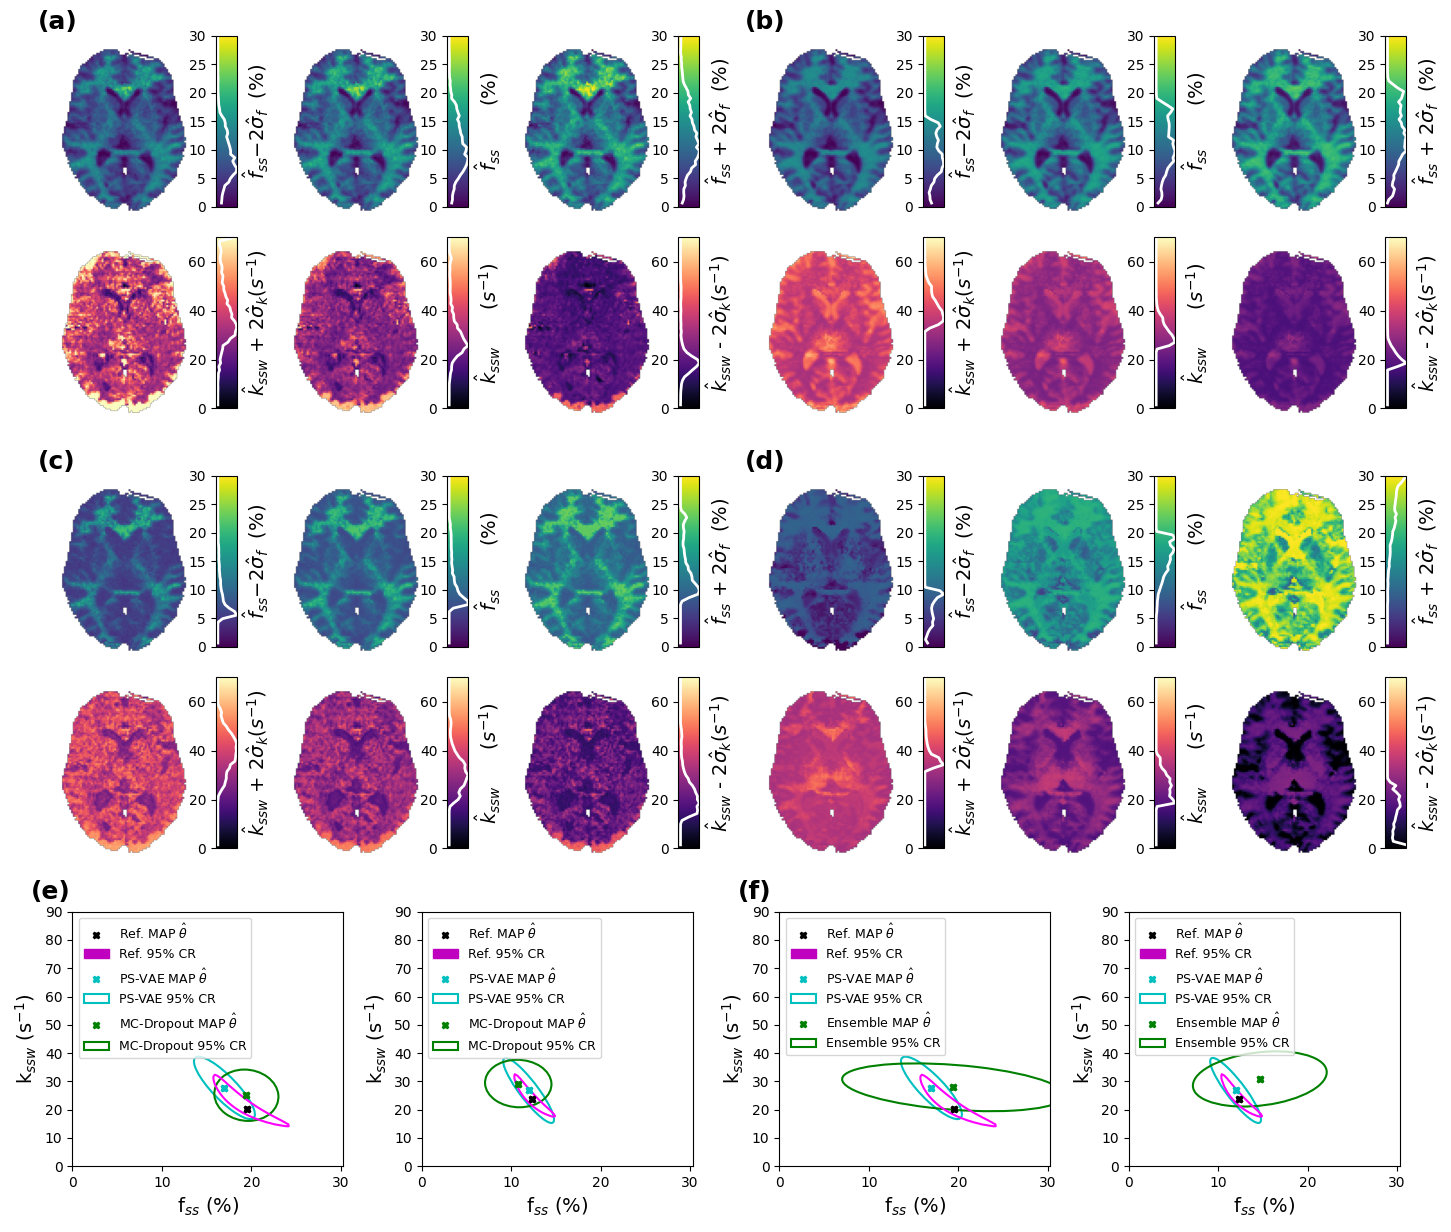

In [68]:
fig = plt.figure(figsize=(14, 12), constrained_layout=True) # 16, 6           
subfigs = fig.subfigures(3, 2, height_ratios=[1, 1, 0.8], hspace=0.1)
cr = 5 

for f, let in zip(subfigs.flatten(), ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]):
    nutils.slap_label_on_container(f, let, loc=(0.03, 1.07) if let in ["(e)", "(f)"] else (0.04, 1.03))
# The "gold standard" - brute-force posterior estimation via full grid likelihood evaluation
au.plot_CI_maps(
        dict_f_est[cr:-cr, cr:-cr], ((dict_est_fCImax-dict_est_fCImin)/4)[cr:-cr, cr:-cr], 
        dict_k_est[cr:-cr, cr:-cr], ((dict_est_kCImax-dict_est_kCImin)/4)[cr:-cr, cr:-cr],
        is_cest=False, vmax_k=70,
        fig=subfigs[0,0], ticks_for_all_cbars=True 
        )

# The proposed method - PS-VAE with full covariance estimation
au.plot_CI_maps(
        f_est[cr:-cr, sli, cr:-cr], f_sigma[cr:-cr, sli, cr:-cr], 
        k_est[cr:-cr, sli, cr:-cr], k_sigma[cr:-cr, sli, cr:-cr],
        is_cest=False, vmax_k=70,
        fig=subfigs[0,1], ticks_for_all_cbars=True 
        )

# Alternative methods - MC-Dropout and Ensemble-based uncertainty estimation
au.viz.plot_CI_maps(
    f_est_mcd[cr:-cr, sli, cr:-cr], np.sqrt(cov_nnpred_scaled_mcd[cr:-cr, sli, cr:-cr, 0,0]), 
    k_est_mcd[cr:-cr, sli, cr:-cr], np.sqrt(cov_nnpred_scaled_mcd[cr:-cr, sli, cr:-cr, 1,1]), 
    is_cest=False, fig=subfigs[1,0], ticks_for_all_cbars=True)
height, width, angle = nutils.cov2ellipse(cov_nnpred_scaled_mcd)   
mcd_nn_pred_dict = {'width': width, 'height': height, 'angle': angle, 'f': f_est_mcd, 'k': k_est_mcd, 'cov_nnpred_scaled': cov_nnpred_scaled_mcd}
_plot_couple_examples(
        subfigs[2,0].subplots(1,2), datafeed_mt, psvae_nn_pred_dict, mcd_nn_pred_dict, 
        _xy=xy_samples, nrmses=nrmses_per_xysamples, do_legend=True, legend_loc='upper left', kmax=90, alt_NN_name='MC-Dropout'
        )

au.viz.plot_CI_maps(
    f_est_ens[cr:-cr, sli, cr:-cr], np.sqrt(cov_nnpred_scaled_ens[cr:-cr, sli, cr:-cr, 0,0]), 
    k_est_ens[cr:-cr, sli, cr:-cr], np.sqrt(cov_nnpred_scaled_ens[cr:-cr, sli, cr:-cr, 1,1]), 
    is_cest=False, fig=subfigs[1,1], ticks_for_all_cbars=True
    )
height, width, angle = nutils.cov2ellipse(cov_nnpred_scaled_ens)   
ens_nn_pred_dict = {'width': width, 'height': height, 'angle': angle, 'f': f_est_ens, 'k': k_est_ens, 'cov_nnpred_scaled': cov_nnpred_scaled_ens}
_plot_couple_examples(subfigs[2,1].subplots(1,2), datafeed_mt, psvae_nn_pred_dict, ens_nn_pred_dict, 
                      _xy=xy_samples, nrmses=nrmses_per_xysamples, do_legend=True, legend_loc='upper left', kmax=90, alt_NN_name='Ensemble'
                      )

### Statistics

In [6]:
for testvolume in ['vol7', 'vol8', 'vol9', 'vol10']:
    print(testvolume)
    pdfs_stash = np.load(f'/home/alexf/phiVAE/figs/humans/vol_pdfs/{testvolume}.npz')
    goodxypoints, allpdfs = pdfs_stash['good_xy_points'], pdfs_stash['allpdfs']
    print(len(goodxypoints),)

vol7
4951
vol8
4729
vol9
4854
vol10
4323


In [7]:
sli = 15
_df_in_perc, _dk = 0.3, 0.7

stochastic_predictor = nutils.get_stochastic_predictor(ckpt_folder=mcdropout_results_dir + "/ckpts/supervised/mt_single") 

def get_KL_medians_for_test_volumes(NN_inference_func):
    KL_medians = []    
    for testvolume in ['vol7', 'vol8', 'vol9', 'vol10']:
        print(testvolume)
        data_xa = xr.open_dataset(f'./data/{testvolume}.nc')
        datafeed_mt = data.SlicesFeed.from_xarray(data_xa, seq_name='mt')
        f_est, k_est, cov_nnpred_scaled, fk_diff = NN_inference_func(datafeed_mt)  
        
        pdfs_stash = np.load(f'/home/alexf/phiVAE/figs/humans/vol_pdfs/{testvolume}.npz')
        goodxypoints, allpdfs = pdfs_stash['good_xy_points'], pdfs_stash['allpdfs']
        allpdfs[0].shape, len(allpdfs)
        distrib_distances_dict_list = []
        for pdf, (_x, _y) in zip(allpdfs, goodxypoints):
            # f_est, k_est, cov_nnpred_scaled, fk_diff
            pdf_NN = au.helpers.gaussian_pdf_2D(
                [f_est[_x, sli, _y], k_est[_x, sli, _y]],
                cov_nnpred_scaled[_x, sli, _y],
                fmax=_df_in_perc * pdf.shape[0], df=_df_in_perc,
                kmax=_dk * pdf.shape[1], dk=_dk
            )
            pdf_NN /= np.sum(pdf_NN)  # discreet-norm as the grid-based PDF
            distrib_distances_dict = au.metrics.compute_dist_distances(pdf, pdf_NN)
            distrib_distances_dict_list.append(distrib_distances_dict)
            KL_median = np.median([d['KL(P1||P2)'] for d in distrib_distances_dict_list])
            KL_medians.append(KL_median)
    print(testvolume, len(distrib_distances_dict_list))
    return KL_medians

KL_medians_mcdropout = get_KL_medians_for_test_volumes(lambda df: nutils.extract_mc_dropout_uncertainty(stochastic_predictor, df, num_samples=20, use_vmap=False))
KL_medians_ensemble = get_KL_medians_for_test_volumes(lambda df: nutils.extract_ensemble_uncertainty(predictors_ensemble, df, mt_sim_mode=mt_sim_mode))

vol7


/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


use_vmap False
Using loop for stochastic forward passes


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 13.66it/s]


vol8
use_vmap False
Using loop for stochastic forward passes


...

vol9


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 15.07it/s]


vol10


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 15.68it/s]


vol10 4323


In [8]:
print(f'{np.mean(KL_medians_mcdropout):.1f} ± {np.std(KL_medians_mcdropout):.1f}')
print(f'{np.mean(KL_medians_ensemble):.1f} ± {np.std(KL_medians_ensemble):.1f}')

2.7 ± 0.4
4.7 ± 0.5


# Removed content here (see prior versions)

* Alternative ways of Failure Analysis (with volunteers / mice)
* e.g. noisy patch, periventricular voxels, residual research, etc.


# Extra human data - CEST of healthy volunteers, MT of Ichilov AD patient

In [68]:
import os, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from importlib import reload    

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "core").exists() and (REPO_ROOT.parent / "core").exists():
    os.chdir(REPO_ROOT.parent)
    REPO_ROOT = Path.cwd()
    
from core import config, data, pipelines; reload(pipelines)
from helpers import loaders
from notebooks import nutils
import analyze_uncertainty as au

config.Config.configure_AMIDE_clinical_whole_brain()

### Erlangen - explore

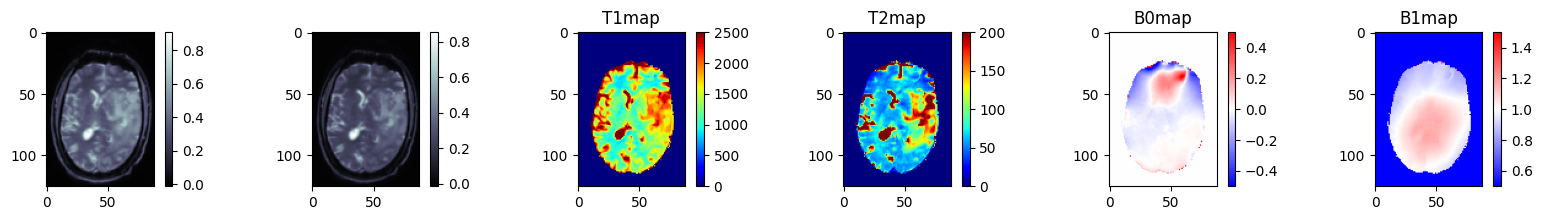

In [69]:
erl_sli = 27
mt_signal, amide_signal, T1ms, T2ms, B0ppm, B1fac, roi_mask_nans = loaders.get_by_name('erlangen')()
loaders.viz(mt_signal, amide_signal, T1ms, T2ms, B0ppm, B1fac, roi_mask_nans, erl_sli)

data_feed_mt, data_feed_amide = [data.SlicesFeed.from_args(
    seq_name=seq_name, drop_first=True,
    shape=T1ms.shape,       
    signal=signal,        
    roi_mask_nans=roi_mask_nans,
    T1a_ms=T1ms, T2a_ms=T2ms,
    B0_shift_ppm_map=B0ppm, B1_fix_factor_map=B1fac
) for seq_name, signal in [('mt', mt_signal), ('amide', amide_signal)]]    

ERL_data_feed_mt, ERL_data_feed_amide = data_feed_mt, data_feed_amide

# amide_tissue_params_est = dict(np.load('figs/patients/erlangen__2026-04-20_00h/intermediates/amide_tissue_params_est.npz'))  # TODO save amide maps in demo_patient!
ckpt_folder_mt, ckpt_folder_cest = [f'/home/alexf/phiVAE/ckpts/patients/erlangen__2026-04-19_22h/{seqname}' for seqname in ['mt', 'cest']]
ERL_ckpt_folder_mt, ERL_ckpt_folder_cest = ckpt_folder_mt, ckpt_folder_cest

In [52]:
from notebooks import nutils
import analyze_uncertainty as au 
from importlib import reload
reload(au.viz); reload(au); reload(nutils); 

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:04<00:00,  4.81s/it]


nrmse_95_th 0.024169018579723534 cdf95 0.946925376916585


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.62s/it]


nrmse_95_th 0.01727654567068652 cdf95 0.9482198334287691


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.63s/it]


nrmse_95_th 0.01485158266615843 cdf95 0.9542428308307759


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.58s/it]


nrmse_95_th 0.02102347332438026 cdf95 0.9474889533311444


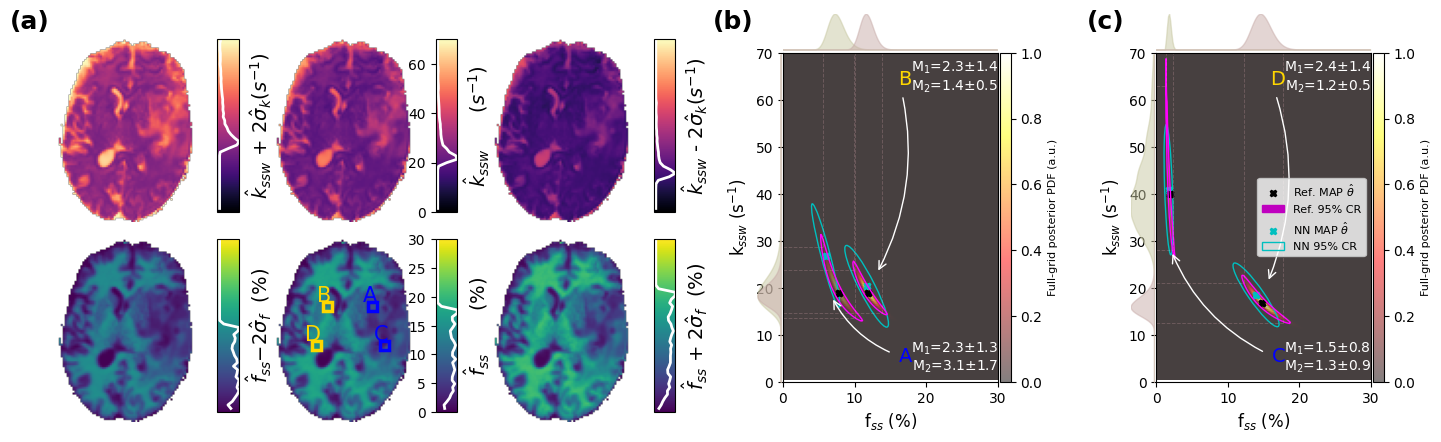

In [53]:
reload(nutils)

mt_tissue_params_est = dict(np.load('figs/humans/erlangen/intermediates/mt_tissue_params_est.npz')) 
nutils.patient_subfigure(data_feed_mt, mt_tissue_params_est)

### Ichilov - explore

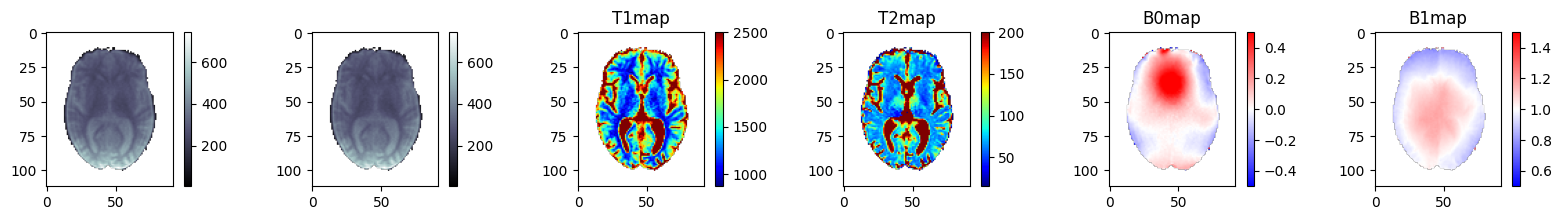

In [58]:
reload(loaders)

ich_alz_sli = 3
# subjdir = /home/alexf/sub4_5_alz/a
mt_signal, amide_signal, T1ms, T2ms, B0ppm, B1fac, roi_mask_nans = loaders.get_by_name('ichilov_alz')() # (subjdir=subjdir)
loaders.viz(mt_signal, amide_signal, T1ms, T2ms, B0ppm, B1fac, roi_mask_nans, ich_alz_sli)

data_feed_mt, data_feed_amide = [data.SlicesFeed.from_args(
    seq_name=seq_name,
    shape=T1ms.shape,       
    signal=signal,        
    roi_mask_nans=roi_mask_nans,
    T1a_ms=T1ms, T2a_ms=T2ms,
    B0_shift_ppm_map=B0ppm, B1_fix_factor_map=B1fac
) for seq_name, signal in [('mt', mt_signal), ('amide', amide_signal)]]    

ICH_ALZ_data_feed_mt, ICH_ALZ_data_feed_amide = data_feed_mt, data_feed_amide

ckpt_folder_mt, ckpt_folder_cest = [f'/home/alexf/phiVAE/ckpts/patients/ichilov_alz__2026-04-20_04h/{seqname}' for seqname in ['mt', 'cest']]
ICH_ALZ_ckpt_folder_mt, ICH_ALZ_ckpt_folder_cest = ckpt_folder_mt, ckpt_folder_cest

## Speed benchmarking of inference

In [74]:
%timeit mt_tissue_params_est, _ellipse_d = nutils.infer_ckpt(ckpt_folder_mt=ERL_ckpt_folder_mt, brain2test_mt=ERL_data_feed_mt)

/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 24.14it/s]
/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsa

875 ms ± 26.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [88]:
new_shape = (ERL_data_feed_mt.shape[0], 1, ERL_data_feed_mt.shape[2])
single_slice_ERL_data_feed_mt = data.SlicesFeed.from_args(seq_name='mt', drop_first=True, shape=new_shape, signal=ERL_data_feed_mt.measured_normed_T[:,:,20:21,:], 
    roi_mask_nans=ERL_data_feed_mt.roi_mask_nans[:,20:21,:], T1a_ms=1000/ERL_data_feed_mt.R1a_V[:,20:21,:], T2a_ms=1000/ERL_data_feed_mt.R2a_V[:,20:21,:],
    B0_shift_ppm_map=ERL_data_feed_mt.B0_shift_ppm_map[:,20:21,:], B1_fix_factor_map=ERL_data_feed_mt.B1_fix_factor_map[:,20:21,:]
    )
%timeit mt_tissue_params_est, _ellipse_d = nutils.infer_ckpt(ckpt_folder_mt=ERL_ckpt_folder_mt, brain2test_mt=single_slice_ERL_data_feed_mt)

/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 24.39it/s]
/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsa

147 ms ± 5.65 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [100]:
new_shape = (1,1,1)
single_voxel_ERL_data_feed_mt = data.SlicesFeed.from_args(seq_name='mt', drop_first=True, shape=new_shape, signal=ERL_data_feed_mt.measured_normed_T[:,:,20:21,:], 
    roi_mask_nans=ERL_data_feed_mt.roi_mask_nans[50:51,20:21,50:51], T1a_ms=1000/ERL_data_feed_mt.R1a_V[50:51,20:21,50:51], T2a_ms=1000/ERL_data_feed_mt.R2a_V[50:51,20:21,50:51    ],
    B0_shift_ppm_map=ERL_data_feed_mt.B0_shift_ppm_map[50:51,20:21,50:51], B1_fix_factor_map=ERL_data_feed_mt.B1_fix_factor_map[50:51,20:21,50:51]
    )
%timeit mt_tissue_params_est, _ellipse_d = nutils.infer_ckpt(ckpt_folder_mt=ERL_ckpt_folder_mt, brain2test_mt=single_voxel_ERL_data_feed_mt)

/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 45.68it/s]
/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsa

140 ms ± 4.47 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


#### CEST

In [96]:
%timeit _, __ = nutils.infer_ckpt(\
    ckpt_folder_mt=ERL_ckpt_folder_mt, ckpt_folder_cest=ERL_ckpt_folder_cest,\
    brain2test_mt=ERL_data_feed_mt, brain2test_cest=ERL_data_feed_amide, is_cest=True\
    )

/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:00<00:00, 29.33it/s]
/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsa

1.72 s ± 49.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [97]:
new_shape = (ERL_data_feed_amide.shape[0], 1, ERL_data_feed_amide.shape[2])
single_slice_ERL_data_feed_mt = data.SlicesFeed.from_args(seq_name='mt', drop_first=True, shape=new_shape, signal=ERL_data_feed_mt.measured_normed_T[:,:,20:21,:], 
    roi_mask_nans=ERL_data_feed_mt.roi_mask_nans[:,20:21,:], T1a_ms=1000/ERL_data_feed_mt.R1a_V[:,20:21,:], T2a_ms=1000/ERL_data_feed_mt.R2a_V[:,20:21,:],
    B0_shift_ppm_map=ERL_data_feed_mt.B0_shift_ppm_map[:,20:21,:], B1_fix_factor_map=ERL_data_feed_mt.B1_fix_factor_map[:,20:21,:]
    )
single_slice_ERL_data_feed_amide = data.SlicesFeed.from_args(seq_name='amide', drop_first=True, shape=new_shape, signal=ERL_data_feed_amide.measured_normed_T[:,:,20:21,:], 
    roi_mask_nans=ERL_data_feed_amide.roi_mask_nans[:,20:21,:], T1a_ms=1000/ERL_data_feed_amide.R1a_V[:,20:21,:], T2a_ms=1000/ERL_data_feed_amide.R2a_V[:,20:21,:],
    B0_shift_ppm_map=ERL_data_feed_amide.B0_shift_ppm_map[:,20:21,:], B1_fix_factor_map=ERL_data_feed_amide.B1_fix_factor_map[:,20:21,:]
    )

%timeit _, __ = nutils.infer_ckpt(\
    ckpt_folder_mt=ERL_ckpt_folder_mt, ckpt_folder_cest=ERL_ckpt_folder_cest,\
    brain2test_mt=single_slice_ERL_data_feed_mt, brain2test_cest=single_slice_ERL_data_feed_amide, is_cest=True\
    )

/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 30.02it/s]
/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsa

210 ms ± 13.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [99]:
new_shape = (1,1,1)
single_voxel_ERL_data_feed_mt = data.SlicesFeed.from_args(seq_name='mt', drop_first=True, shape=new_shape, signal=ERL_data_feed_mt.measured_normed_T[:,:,20:21,:], 
    roi_mask_nans=ERL_data_feed_mt.roi_mask_nans[50:51,20:21,50:51], T1a_ms=1000/ERL_data_feed_mt.R1a_V[50:51,20:21,50:51], T2a_ms=1000/ERL_data_feed_mt.R2a_V[50:51,20:21,50:51    ],
    B0_shift_ppm_map=ERL_data_feed_mt.B0_shift_ppm_map[50:51,20:21,50:51], B1_fix_factor_map=ERL_data_feed_mt.B1_fix_factor_map[50:51,20:21,50:51]
    )
single_voxel_ERL_data_feed_amide = data.SlicesFeed.from_args(seq_name='amide', drop_first=True, shape=new_shape, signal=ERL_data_feed_amide.measured_normed_T[:,:,20:21,:], 
    roi_mask_nans=ERL_data_feed_amide.roi_mask_nans[50:51,20:21,50:51], T1a_ms=1000/ERL_data_feed_amide.R1a_V[50:51,20:21,50:51], T2a_ms=1000/ERL_data_feed_amide.R2a_V[50:51,20:21,50:51    ],
    B0_shift_ppm_map=ERL_data_feed_amide.B0_shift_ppm_map[50:51,20:21,50:51], B1_fix_factor_map=ERL_data_feed_amide.B1_fix_factor_map[50:51,20:21,50:51]
    )

%timeit _, __ = nutils.infer_ckpt(\
    ckpt_folder_mt=ERL_ckpt_folder_mt, ckpt_folder_cest=ERL_ckpt_folder_cest,\
    brain2test_mt=single_voxel_ERL_data_feed_mt, brain2test_cest=single_voxel_ERL_data_feed_amide, is_cest=True\
    )

/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 48.93it/s]
/home/alexf/phiVAE/core/pipelines.py:242: RuntimeWarning: invalid value encountered in divide
  err_3d /= np.linalg.norm(
/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time wi

209 ms ± 9 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)



/home/alexf/phiVAE/core/pipelines.py:242: RuntimeWarning: invalid value encountered in divide
  err_3d /= np.linalg.norm(


## FINAL FIGURE - Patients (Fig. 5)

/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.63s/it]


nrmse_95_th 0.024169018579723534 cdf95 0.946925376916585


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.64s/it]


nrmse_95_th 0.01727654567068652 cdf95 0.9482198334287691


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.74s/it]


...

nrmse_95_th 0.03322858276065822 cdf95 0.9482297398765817


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.73s/it]


nrmse_95_th 0.02582383849265524 cdf95 0.9460730811178366


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.70s/it]


nrmse_95_th 0.03603500449488162 cdf95 0.9496298512612877


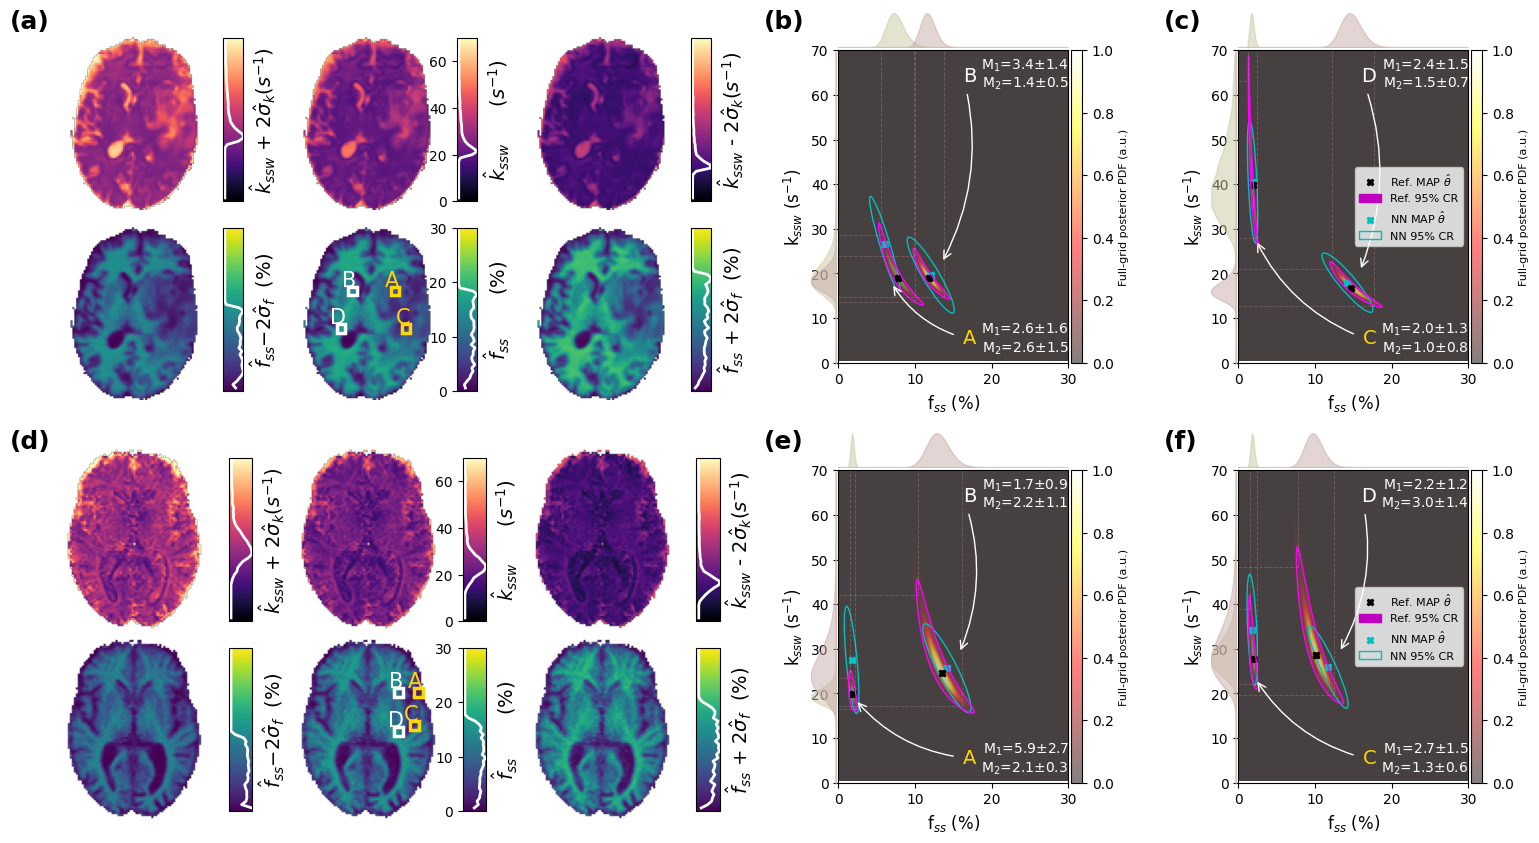

In [68]:
reload(nutils)
do_cest_patients = False

if do_cest_patients:
    figure = plt.figure(figsize=(15, 16), constrained_layout=True)
    subfigs = figure.subfigures(4, 1, hspace=0.1)
else:
    figure = plt.figure(figsize=(15, 8), constrained_layout=True)
    subfigs = figure.subfigures(2, 1, hspace=0.1)

mt_tissue_params_est, _ellipse_d = nutils.infer_ckpt(ckpt_folder_mt=ERL_ckpt_folder_mt, brain2test_mt=ERL_data_feed_mt)
nutils.patient_subfigure(data_feed_mt=ERL_data_feed_mt, tissue_params_est=mt_tissue_params_est, sli=erl_sli, drop_first=True, fig=subfigs[0])

if do_cest_patients:
    amide_tissue_params_est, _ellipse_d = nutils.infer_ckpt(ckpt_folder_mt=ERL_ckpt_folder_mt, brain2test_mt=ERL_data_feed_mt, is_cest=True, ckpt_folder_cest=ERL_ckpt_folder_cest, brain2test_cest=ERL_data_feed_amide)
    nutils.patient_subfigure(
        data_feed_mt=ERL_data_feed_mt, data_feed_cest=ERL_data_feed_amide, tissue_params_est=amide_tissue_params_est, 
        is_cest=True, max_k_cest=350, annotate_cross_mahas=False, sli=erl_sli, drop_first=True, 
        fig=subfigs[1], letters='def'    
    ) 

# ======================================================================================
mt_tissue_params_est, _ellipse_d = nutils.infer_ckpt(ckpt_folder_mt=ICH_ALZ_ckpt_folder_mt, brain2test_mt=ICH_ALZ_data_feed_mt) #, is_cest=True, ckpt_folder_cest=ckpt_folder_cest, brain2test_cest=data_feed_amide)
nutils.patient_subfigure(
    data_feed_mt=ICH_ALZ_data_feed_mt, tissue_params_est=mt_tissue_params_est, 
    sli=ich_alz_sli, points_ABCD=[(35, 70), (35, 60), (52, 68), (55, 60)], drop_first=False, cropy1=10,
    fig=subfigs[2] if do_cest_patients else subfigs[1], letters='ghi' if do_cest_patients else 'def'
)

if do_cest_patients:
    amide_tissue_params_est, _ellipse_d = nutils.infer_ckpt(
        ckpt_folder_mt=ICH_ALZ_ckpt_folder_mt, brain2test_mt=ICH_ALZ_data_feed_mt, 
        is_cest=True, ckpt_folder_cest=ICH_ALZ_ckpt_folder_cest, brain2test_cest=ICH_ALZ_data_feed_amide
    )
    nutils.patient_subfigure(
        data_feed_mt=ICH_ALZ_data_feed_mt, data_feed_cest=ICH_ALZ_data_feed_amide, tissue_params_est=amide_tissue_params_est, 
        is_cest=True, max_k_cest=350, annotate_cross_mahas=False, sli=ich_alz_sli, points_ABCD=[(35, 60), (35, 70), (55, 60), (55, 70)], drop_first=False, cropy1=10,
        fig=subfigs[3], letters='jkl'    
    ) 
    
plt.savefig('figs/humans/patients_mt.png', dpi=300, bbox_inches='tight')
plt.savefig('figs/humans/patients_mt_LOWRES.png', dpi=300, bbox_inches='tight')


## Create NRMSE for different slices of patients (used in summary.ipynb for stats figure )

In [54]:
reload(nutils)

mt_tissue_params_est_ALZ, _ellipse_d = nutils.infer_ckpt(ckpt_folder_mt=ICH_ALZ_ckpt_folder_mt, brain2test_mt=ICH_ALZ_data_feed_mt, do_forward=True)

/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:11<00:00,  3.91s/it]


In [ ]:
from dictionary_methods import dictbased_runner, dict_matcher

tissue_parameter_ranges_od = data.def_ranges4LHS
tissue_parameter_ranges_od['fc_gt_T'] = [0.01, 0.3]
tissue_parameter_ranges_od['kc_gt_T'] = [2, 70]
mt_dict_as3dfeed = dictbased_runner.get_dict(tissue_parameter_ranges_od=tissue_parameter_ranges_od)
_f_best_ALZ, _k_best_ALZ, best_match_ALZ, err_3d_dict_ALZ = \
        dictbased_runner.match_to_dict(mt_dict_as3dfeed, ICH_ALZ_data_feed_mt, constrain_T1T2=False)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:11<00:00,  5.76s/it]


Dict match of slice: 0
Dict match of slice: 1
Dict match of slice: 2
Dict match of slice: 3
Dict match of slice: 4
Dict match of slice: 5
Dict match of slice: 6
Dict match of slice: 7
Dict match of slice: 8
Dict match of slice: 9
Dict match of slice: 10
Dict match of slice: 11


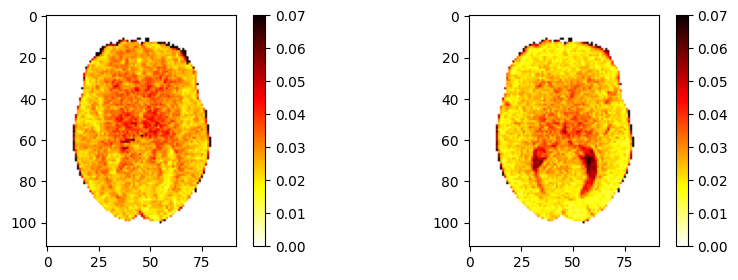

In [78]:
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.imshow(mt_tissue_params_est_ALZ['err_mt'][:,3,:], cmap='hot_r', vmin=0, vmax=0.07); plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(err_3d_dict_ALZ[:,3,:], cmap='hot_r', vmin=0, vmax=0.07); plt.colorbar()

In [60]:
mt_tissue_params_est_ERL, _ellipse_d = nutils.infer_ckpt(ckpt_folder_mt=ERL_ckpt_folder_mt, brain2test_mt=ERL_data_feed_mt, do_forward=True)

/home/alexf/anaconda3/envs/nbmf1/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1251: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:45<00:00,  4.56s/it]


In [84]:
reload(dictbased_runner)
mt_dict_as3dfeed = dictbased_runner.get_dict(seq_df=data.read_sequence('mt', drop_first=True))
_f_best_ERL, _k_best_ERL, best_match_ERL, err_3d_dict_ERL = \
        dictbased_runner.match_to_dict(mt_dict_as3dfeed, ERL_data_feed_mt, constrain_T1T2=False)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:10<00:00,  5.37s/it]


Dict match of slice: 0
Dict match of slice: 1
Dict match of slice: 2
Dict match of slice: 3
Dict match of slice: 4
Dict match of slice: 5
Dict match of slice: 6
Dict match of slice: 7
Dict match of slice: 8
Dict match of slice: 9
Dict match of slice: 10
Dict match of slice: 11
Dict match of slice: 12
Dict match of slice: 13
Dict match of slice: 14
Dict match of slice: 15
Dict match of slice: 16
Dict match of slice: 17
Dict match of slice: 18
Dict match of slice: 19
Dict match of slice: 20
Dict match of slice: 21
Dict match of slice: 22
Dict match of slice: 23
Dict match of slice: 24
Dict match of slice: 25
Dict match of slice: 26
Dict match of slice: 27
Dict match of slice: 28
Dict match of slice: 29
Dict match of slice: 30
Dict match of slice: 31
Dict match of slice: 32
Dict match of slice: 33
Dict match of slice: 34
Dict match of slice: 35
Dict match of slice: 36
Dict match of slice: 37
Dict match of slice: 38
Dict match of slice: 39
Dict match of slice: 40
Dict match of slice: 41
Di

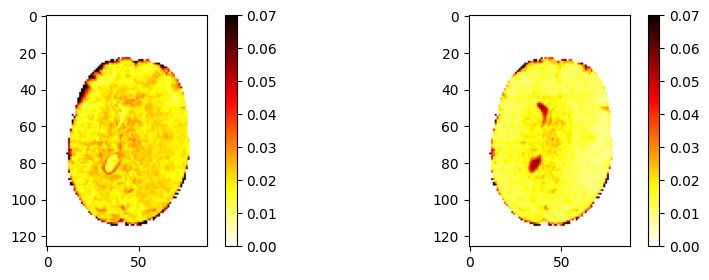

In [ ]:
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.imshow(mt_tissue_params_est_ERL['err_mt'][:,30,:], cmap='hot_r', vmin=0, vmax=0.07); plt.colorbar()
plt.subplot(1, 2, 2)
plt.imshow(err_3d_dict_ERL[:,30,:], cmap='hot_r', vmin=0, vmax=0.07); plt.colorbar()

In [86]:
np.savez('figs/patients/nrmse_nn_vs_dict.npz',
            nn_err_erl=mt_tissue_params_est_ERL['err_mt'], 
            nn_err_alz=mt_tissue_params_est_ALZ['err_mt'], 
            dict_err_erl=err_3d_dict_ERL, 
            dict_err_alz=err_3d_dict_ALZ)

## Removed content here - see prior versions

* Exploring alternative figure layouts for human data
* More debugging / validation / drill-down code
* Exploring CEST neural-fitting for Patients
* Exploring Bayesian nuance (Mean vs. Mode)